In [1]:
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [2]:
titanic_data = sns.load_dataset("titanic")
titanic_data.head()
titanic_data.describe
titanic_data.isnull().sum()


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [3]:
titanic_data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
features = ["pclass","age","sex","fare","embarked"]
target = ["survived"]

In [5]:
## Handle missing values 
from sklearn.impute import SimpleImputer
imp_median = SimpleImputer(strategy="median")
imp_mode = SimpleImputer(strategy="most_frequent")

titanic_data["age"]= imp_median.fit_transform(titanic_data[["age"]]).ravel() ## imputer retyrns 2d df ravel converts it into (n,1)=>(n)
titanic_data["embarked"]= imp_mode.fit_transform(titanic_data[["embarked"]]).ravel()

In [6]:
titanic_data.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [7]:
## Encode our features
titanic_data.head()

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

titanic_data["sex"] = le.fit_transform(titanic_data["sex"])
titanic_data["embarked"] = le.fit_transform(titanic_data["embarked"])

In [8]:
titanic_data["embarked"].dtype
titanic_data["sex"].dtype

dtype('int64')

In [9]:
X = titanic_data[features]
y = titanic_data[target]

In [10]:
X_train , X_test , y_train, y_test = train_test_split(X , y , test_size=0.2, random_state=42)

In [11]:
X_train.head()

,pclass,age,sex,fare,embarked
331,1,45.5,1,28.5000,2
733,2,23.0,1,13.0000,2
382,3,32.0,1,7.9250,2
704,3,26.0,1,7.8542,2
813,3,6.0,0,31.2750,2


In [12]:
y_train.head()

,survived
331,0
733,0
382,0
704,0
813,0


In [13]:
model = DecisionTreeClassifier()
model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [14]:
acc = model.score(X_test,y_test)
print(acc)

0.7653631284916201


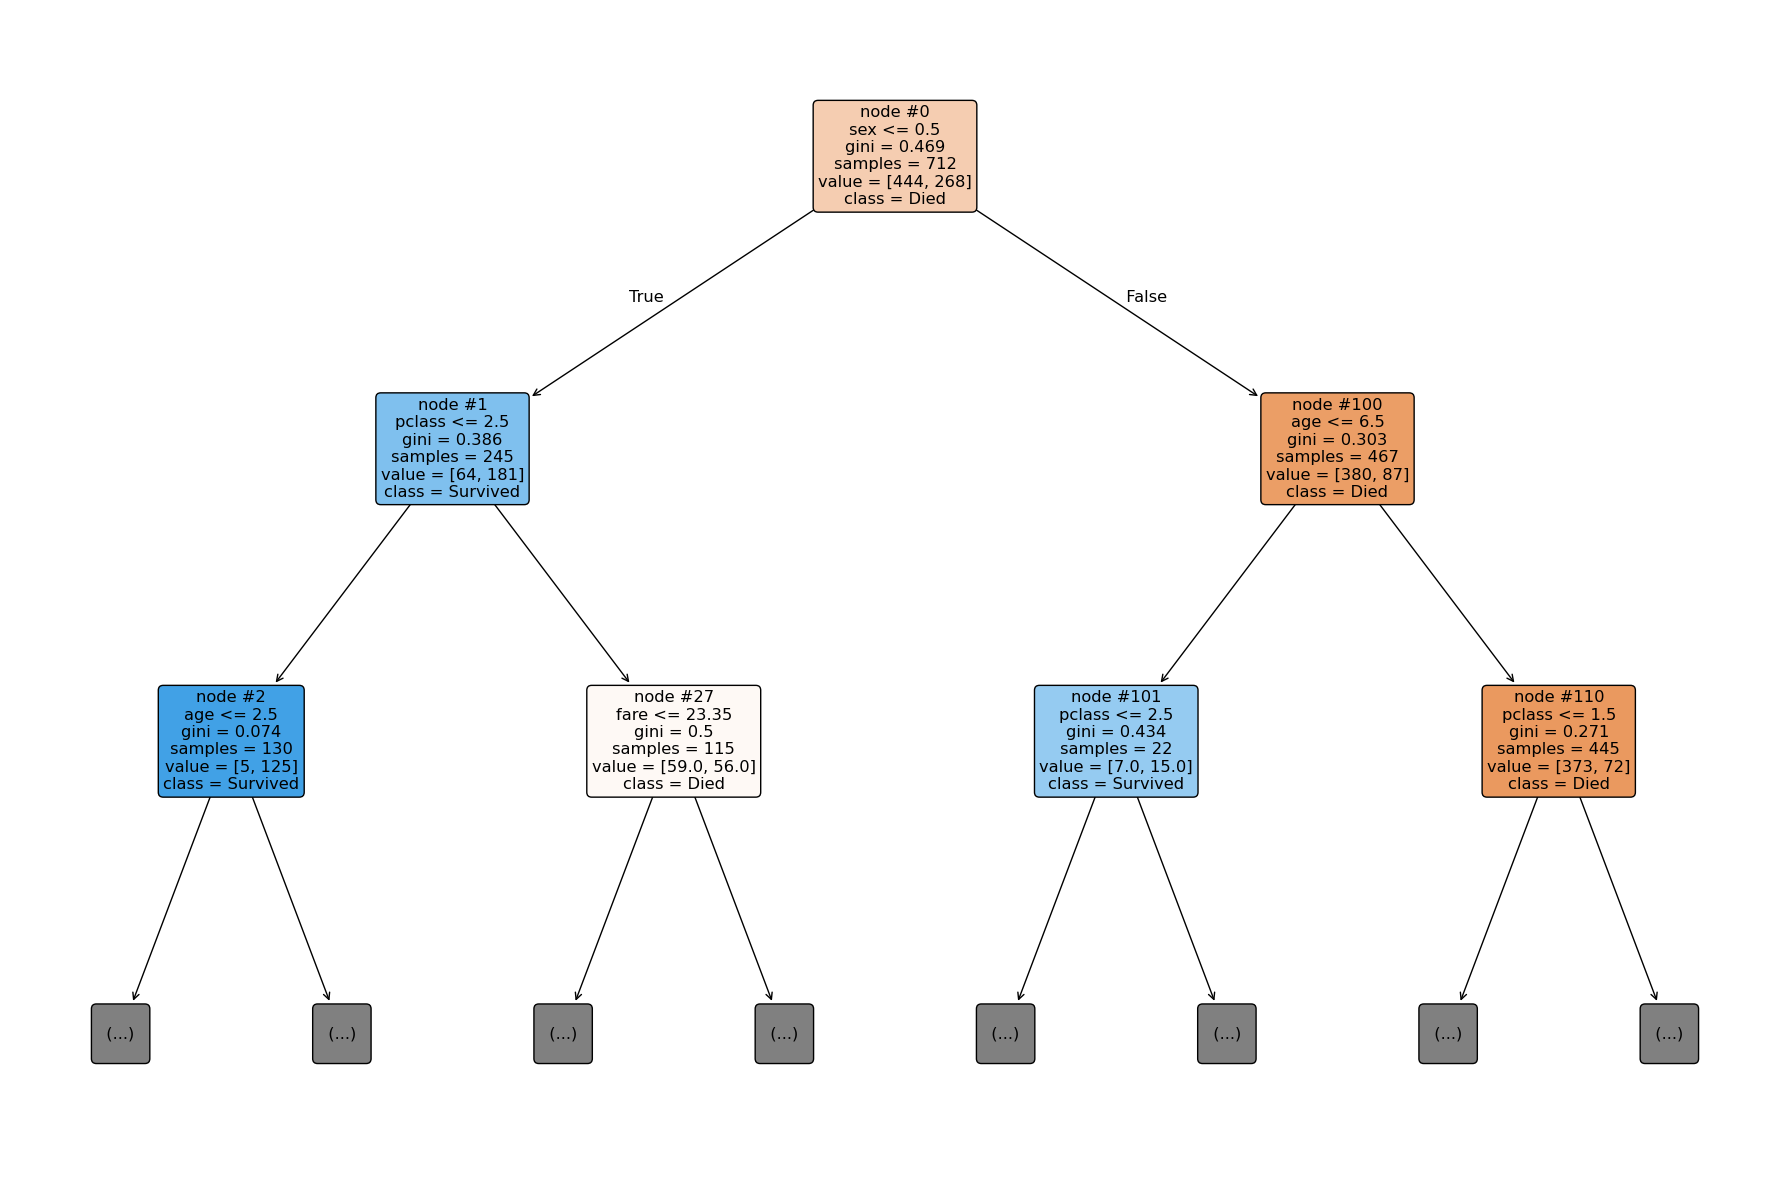

In [15]:
## plottining decision Tree 
from sklearn.tree import plot_tree
plt.figure(figsize=(18,12))
plot_tree(
    model,
    feature_names = X.columns,
    class_names = ["Died","Survived"],
    filled = True,
    node_ids = True,
    rounded = True,
    max_depth = 2
)

plt.tight_layout()
plt.show()

# Decision Tree with pre pruning

In [16]:
## based on the max depth we get highest accuracy for our model
max_depth = [2,3,4,5,6,7,8,9,10]

for depth in max_depth:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train,y_train)

    acc_score = model.score(X_test,y_test)
    print(f"acuracy score based on {depth} depth acc is{acc_score}")
    

acuracy score based on 2 depth acc is0.7653631284916201
acuracy score based on 3 depth acc is0.7988826815642458
acuracy score based on 4 depth acc is0.7988826815642458
acuracy score based on 5 depth acc is0.7988826815642458
acuracy score based on 6 depth acc is0.7988826815642458
acuracy score based on 7 depth acc is0.7932960893854749
acuracy score based on 8 depth acc is0.7988826815642458
acuracy score based on 9 depth acc is0.7877094972067039
acuracy score based on 10 depth acc is0.7988826815642458


acuracy score based on 6 depth acc is0.8044692737430168


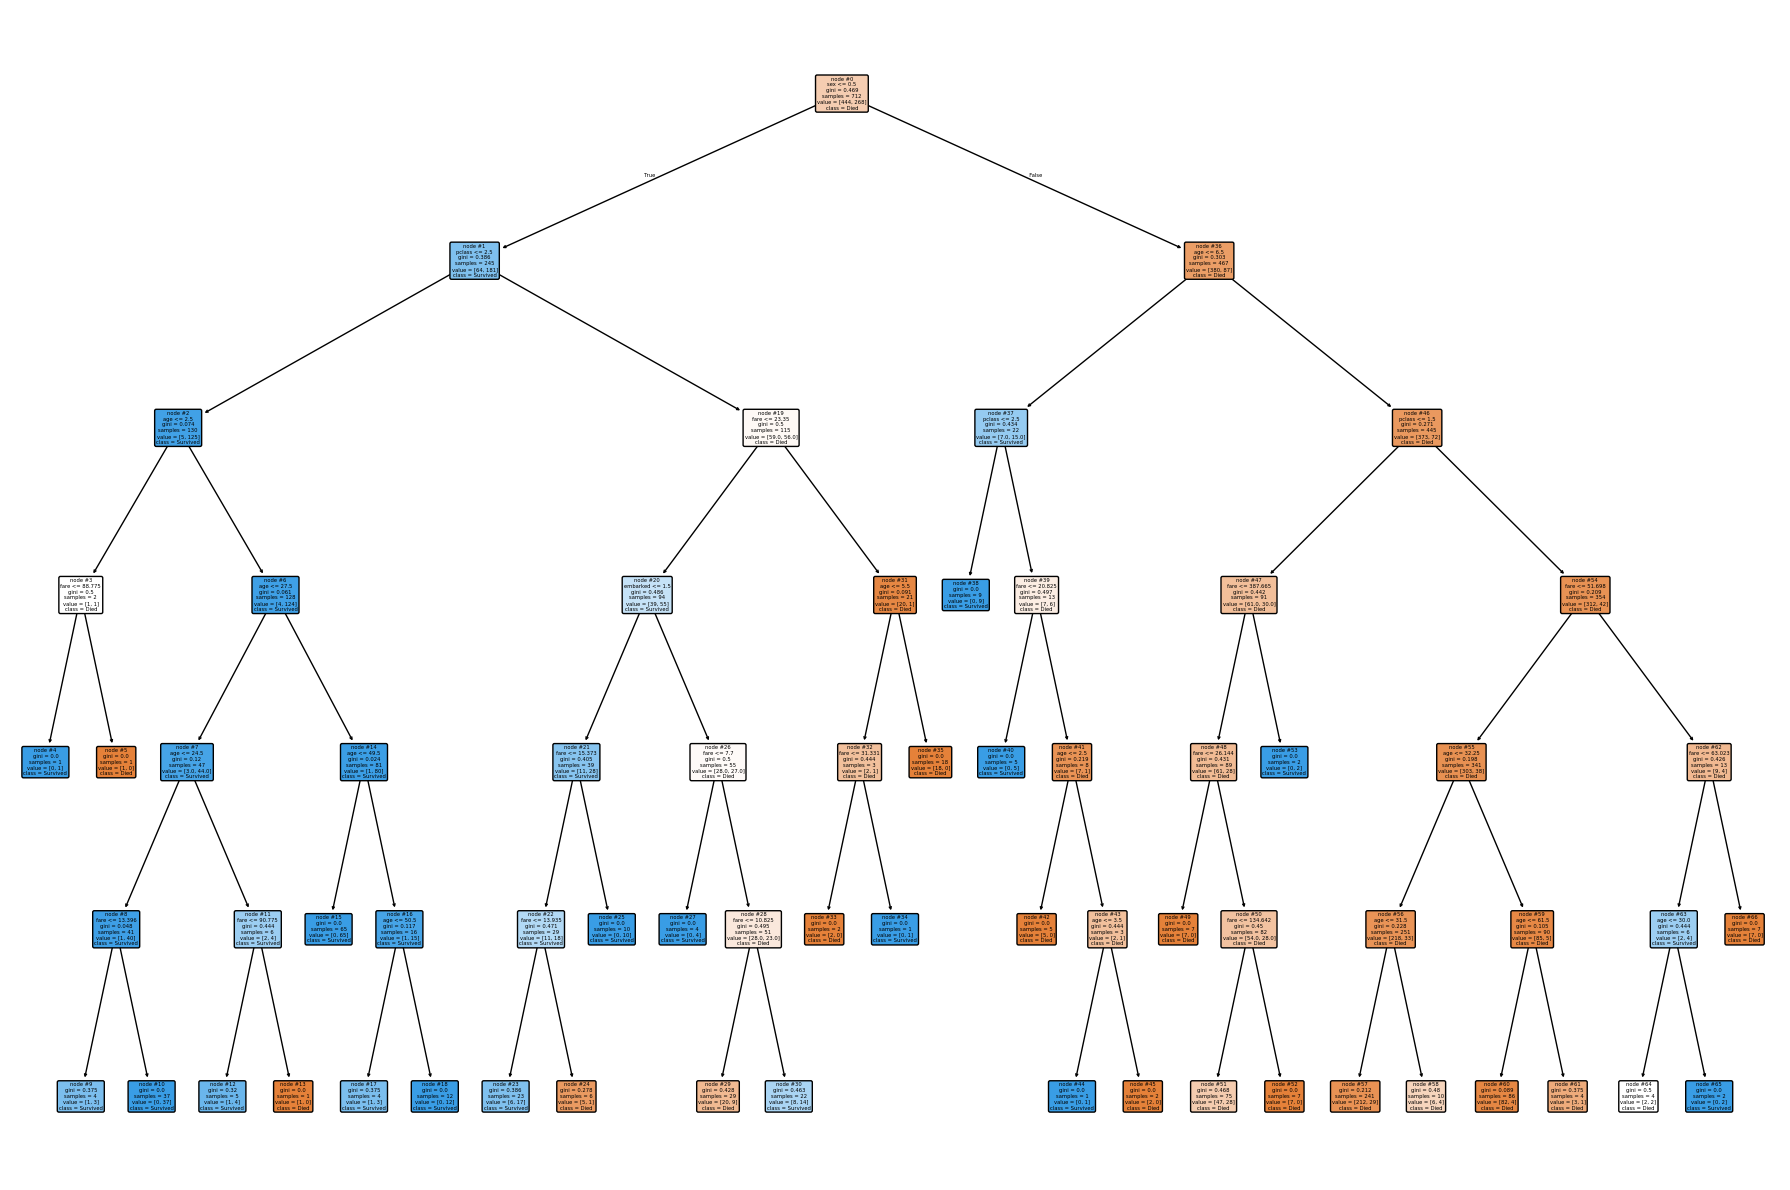

In [17]:
## we get best accuracy on depth 6 so based on the depth 6 we train the model on max_depth =6
model = DecisionTreeClassifier(max_depth=6)
model.fit(X_train,y_train)

acc_score = model.score(X_test,y_test)
print(f"acuracy score based on 6 depth acc is{acc_score}")

plt.figure(figsize=(18,12))
plot_tree(
    model,
    feature_names = X.columns,
    class_names = ["Died","Survived"],
    filled = True,
    node_ids = True,
    rounded = True,
)

plt.tight_layout()
plt.show()
    
    

# Post Pruning 

In [18]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [19]:
path = model.cost_complexity_pruning_path(X_train,y_train)
path

{'ccp_alphas': array([0.00000000e+00, 0.00000000e+00, 6.68806849e-05, 1.45921494e-04,
        1.84428555e-04, 2.00642055e-04, 2.34082397e-04, 2.34082397e-04,
        3.51123596e-04, 4.68164794e-04, 4.68164794e-04, 5.61797753e-04,
        6.24219725e-04, 6.67991230e-04, 7.02247191e-04, 7.02247191e-04,
        8.19288390e-04, 8.19288390e-04, 8.32292967e-04, 8.42696629e-04,
        8.42696629e-04, 8.42696629e-04, 8.94231048e-04, 8.99610781e-04,
        9.24769963e-04, 9.36329588e-04, 9.36329588e-04, 9.36329588e-04,
        9.88347898e-04, 1.00253471e-03, 1.05337079e-03, 1.07400895e-03,
        1.08038029e-03, 1.11865144e-03, 1.12359551e-03, 1.12359551e-03,
        1.13139825e-03, 1.17041199e-03, 1.18841832e-03, 1.22566125e-03,
        1.22893258e-03, 1.22893258e-03, 1.24361593e-03, 1.24843945e-03,
        1.27565833e-03, 1.30996111e-03, 1.33761370e-03, 1.37044603e-03,
        1.46301498e-03, 1.47927070e-03, 1.51142557e-03, 1.54072312e-03,
        1.56675436e-03, 1.60434338e-03, 1.66892062

In [20]:
ccp_alphas = path.ccp_alphas
ccp_alphas

array([0.00000000e+00, 0.00000000e+00, 6.68806849e-05, 1.45921494e-04,
       1.84428555e-04, 2.00642055e-04, 2.34082397e-04, 2.34082397e-04,
       3.51123596e-04, 4.68164794e-04, 4.68164794e-04, 5.61797753e-04,
       6.24219725e-04, 6.67991230e-04, 7.02247191e-04, 7.02247191e-04,
       8.19288390e-04, 8.19288390e-04, 8.32292967e-04, 8.42696629e-04,
       8.42696629e-04, 8.42696629e-04, 8.94231048e-04, 8.99610781e-04,
       9.24769963e-04, 9.36329588e-04, 9.36329588e-04, 9.36329588e-04,
       9.88347898e-04, 1.00253471e-03, 1.05337079e-03, 1.07400895e-03,
       1.08038029e-03, 1.11865144e-03, 1.12359551e-03, 1.12359551e-03,
       1.13139825e-03, 1.17041199e-03, 1.18841832e-03, 1.22566125e-03,
       1.22893258e-03, 1.22893258e-03, 1.24361593e-03, 1.24843945e-03,
       1.27565833e-03, 1.30996111e-03, 1.33761370e-03, 1.37044603e-03,
       1.46301498e-03, 1.47927070e-03, 1.51142557e-03, 1.54072312e-03,
       1.56675436e-03, 1.60434338e-03, 1.66892062e-03, 1.76144762e-03,
      

In [21]:
## train the model on the basis of ccp_alpha to finf the accuracy
tree = []
for alphas in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42,ccp_alpha=alphas)
    model.fit(X_train,y_train)

    tree.append((model,alphas))

In [22]:
best_acc=0
best_alpha =0

for model , alpha in tree:
    curr_acc = model.score(X_test,y_test)
    if curr_acc > best_acc:
        best_acc = curr_acc
        best_alpha = alpha
        
    

In [23]:
best_acc

0.8379888268156425

In [24]:
best_alpha

np.float64(0.0015407231242023183)

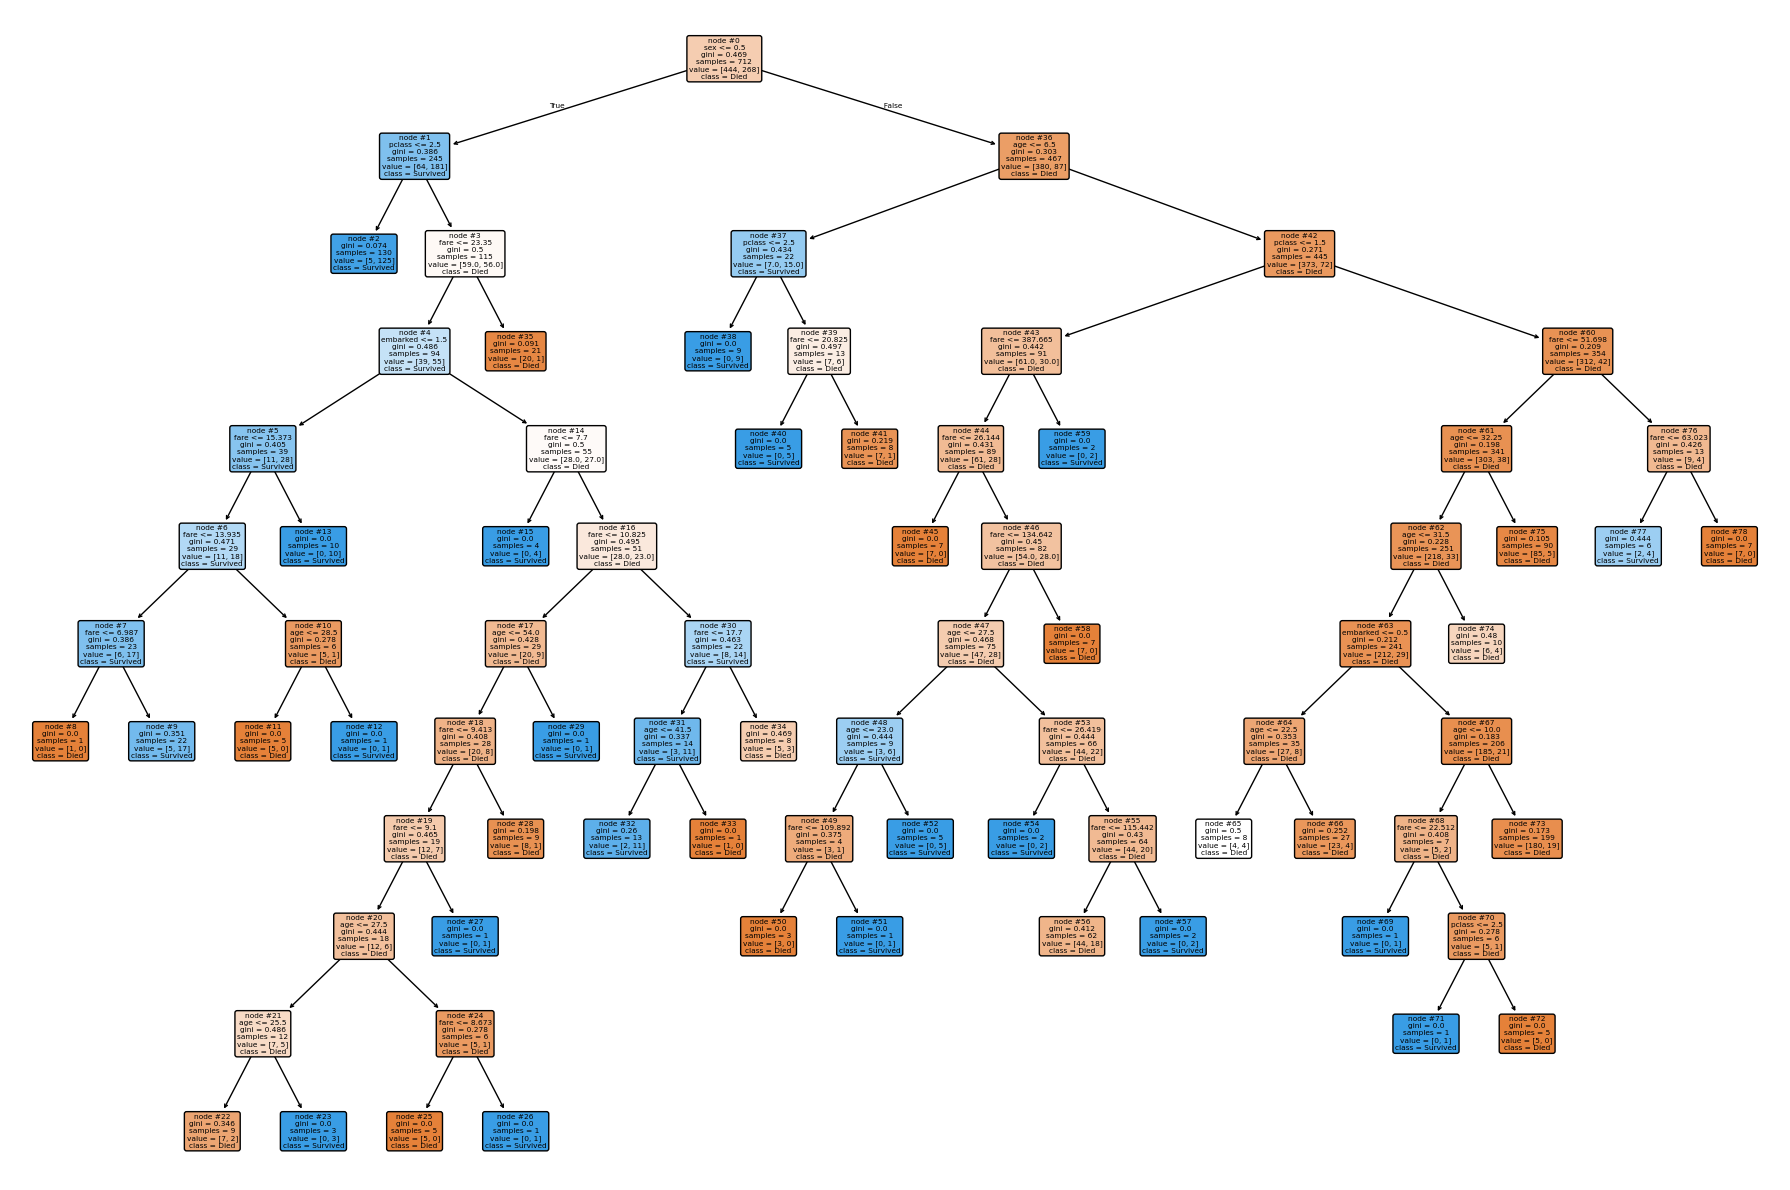

In [25]:
best_model = DecisionTreeClassifier(random_state=42,ccp_alpha=best_alpha)
best_model.fit(X_train,y_train)
plt.figure(figsize=(18,12))
plot_tree(
    best_model,
    feature_names = X.columns,
    class_names = ["Died","Survived"],
    filled = True,
    node_ids = True,
    rounded = True,
)

plt.tight_layout()
plt.show()

# Combination of pre and post pruning


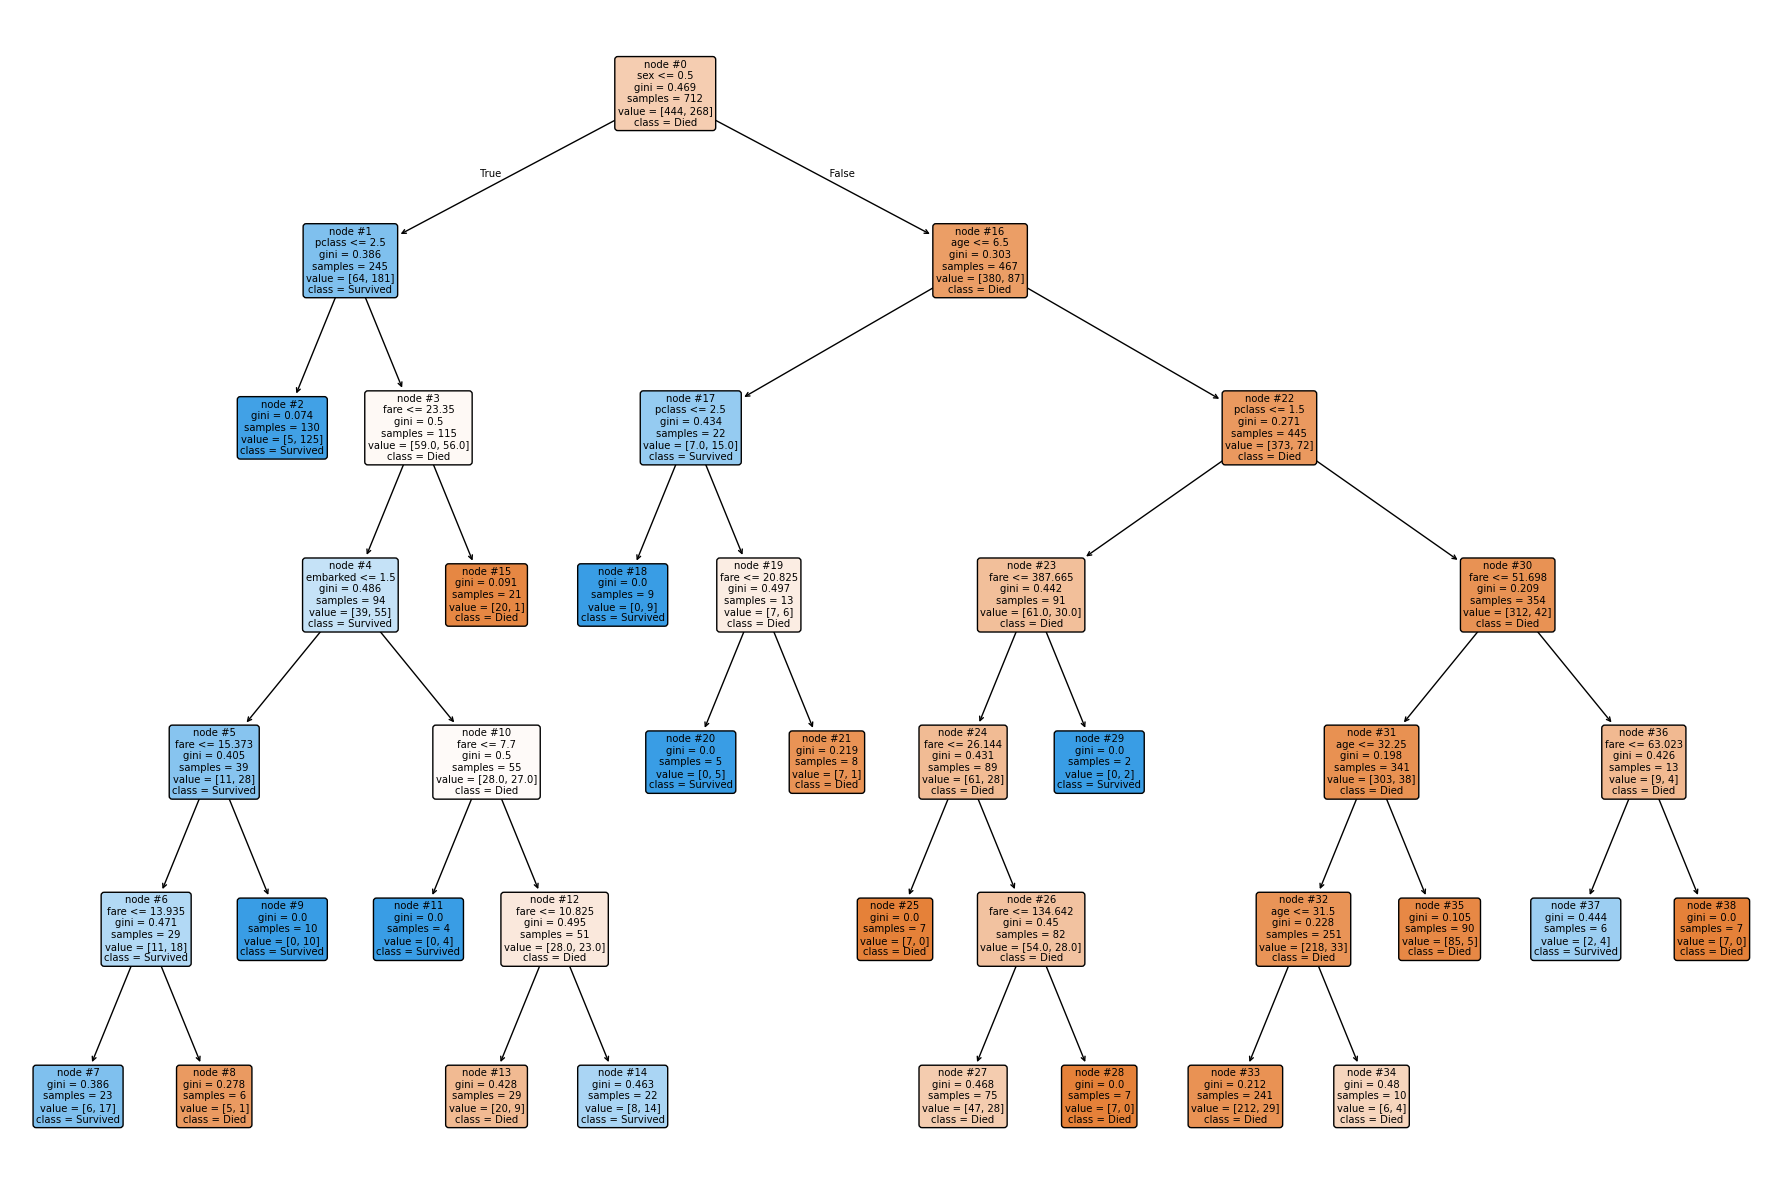

0.8100558659217877


In [26]:
best_model = DecisionTreeClassifier(random_state=42,ccp_alpha=best_alpha,max_depth=6)
best_model.fit(X_train,y_train)
plt.figure(figsize=(18,12))
plot_tree(
    best_model,
    feature_names = X.columns,
    class_names = ["Died","Survived"],
    filled = True,
    node_ids = True,
    rounded = True,
)

plt.tight_layout()
plt.show()
print(best_model.score(X_test,y_test))